In [4]:
import torch
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '2'

from simpleMB import SimpleMB

import numpy as np
import matplotlib.pyplot as plt

class Args():
    pass

args = Args()
args.device = "cuda"

In [5]:
potential = SimpleMB(args,n_in=2)

x0, xf = potential.initial_point.detach(), potential.final_point.detach()

potential.force_func(x0)

/home/sanjeevr/miniforge3/envs/om-diffusion/lib/python3.12/site-packages/torch/_functorch/deprecated.py:65: UserWarning: We've integrated functorch into PyTorch. As the final step of the integration, functorch.grad is deprecated as of PyTorch 2.0 and will be deleted in a future version of PyTorch >= 2.3. Please use torch.func.grad instead; see the PyTorch 2.0 release notes and/or the torch.func migration guide for more details https://pytorch.org/docs/master/func.migrating.html
  warn_deprecated('grad')


(tensor(0, device='cuda:0'), tensor([-0.5904,  0.7353], device='cuda:0'))

In [6]:
def S2_action(path, xi, dt, D):
    """Action containing hessian."""    
    first_term = torch.square((path[1:,:] - path[:-1,:])) * (xi/4/ dt)
    second_term = torch.square(potential.force_func(path[:-1,:])[1]) * (dt/4/xi)
    third_term = potential.laplace(path[:-1,:]) * (dt* D / torch.tensor(2.0))
    result = torch.sum(first_term + second_term + third_term)
    return result

def simple_action(path, xi, dt, D=None):
    """Action without hessian."""
    # for i in range(path.shape[0]-1):
    first_term = torch.square((path[1:] - path[:-1])) * (xi/ dt)
    f_n = potential.force_func(path[:-1])[1]
    f_np = potential.force_func(path[1:])[1]
    second_term = (torch.square(f_n) + torch.square(f_np)) * (dt/xi/2.0)
    third_term = (path[1:] - path[:-1]) * (f_np - f_n)
    result = torch.sum(first_term + second_term + third_term)
    return result / torch.tensor(4.0)

wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


MB_simple_xi=0.0_dt=0.009999999776482582_D=0.0


  0%|          | 0/500 [00:00<?, ?it/s]/home/sanjeevr/miniforge3/envs/om-diffusion/lib/python3.12/site-packages/torch/_functorch/deprecated.py:65: UserWarning: We've integrated functorch into PyTorch. As the final step of the integration, functorch.grad is deprecated as of PyTorch 2.0 and will be deleted in a future version of PyTorch >= 2.3. Please use torch.func.grad instead; see the PyTorch 2.0 release notes and/or the torch.func migration guide for more details https://pytorch.org/docs/master/func.migrating.html
  warn_deprecated('grad')
/tmp/ipykernel_2092703/2523849223.py:94: MatplotlibDeprecationWarning: The tostring_rgb function was deprecated in Matplotlib 3.8 and will be removed in 3.10. Use buffer_rgba instead.
  image = np.frombuffer(fig.canvas.tostring_rgb(), dtype='uint8')
100%|██████████| 500/500 [00:06<00:00, 74.86it/s] 


final_action,▁
final_action,26.09777


MB_simple_xi=0.0_dt=0.03162277489900589_D=0.0


  0%|          | 0/500 [00:00<?, ?it/s]/home/sanjeevr/miniforge3/envs/om-diffusion/lib/python3.12/site-packages/torch/_functorch/deprecated.py:65: UserWarning: We've integrated functorch into PyTorch. As the final step of the integration, functorch.grad is deprecated as of PyTorch 2.0 and will be deleted in a future version of PyTorch >= 2.3. Please use torch.func.grad instead; see the PyTorch 2.0 release notes and/or the torch.func migration guide for more details https://pytorch.org/docs/master/func.migrating.html
  warn_deprecated('grad')
/tmp/ipykernel_2092703/2523849223.py:94: MatplotlibDeprecationWarning: The tostring_rgb function was deprecated in Matplotlib 3.8 and will be removed in 3.10. Use buffer_rgba instead.
  image = np.frombuffer(fig.canvas.tostring_rgb(), dtype='uint8')
100%|██████████| 500/500 [00:06<00:00, 76.94it/s] 


final_action,▁
final_action,48.73204


MB_simple_xi=0.0_dt=0.10000000149011612_D=0.0


  0%|          | 0/500 [00:00<?, ?it/s]/home/sanjeevr/miniforge3/envs/om-diffusion/lib/python3.12/site-packages/torch/_functorch/deprecated.py:65: UserWarning: We've integrated functorch into PyTorch. As the final step of the integration, functorch.grad is deprecated as of PyTorch 2.0 and will be deleted in a future version of PyTorch >= 2.3. Please use torch.func.grad instead; see the PyTorch 2.0 release notes and/or the torch.func migration guide for more details https://pytorch.org/docs/master/func.migrating.html
  warn_deprecated('grad')
/tmp/ipykernel_2092703/2523849223.py:94: MatplotlibDeprecationWarning: The tostring_rgb function was deprecated in Matplotlib 3.8 and will be removed in 3.10. Use buffer_rgba instead.
  image = np.frombuffer(fig.canvas.tostring_rgb(), dtype='uint8')
 18%|█▊        | 88/500 [00:01<00:05, 77.70it/s] 


KeyboardInterrupt: 

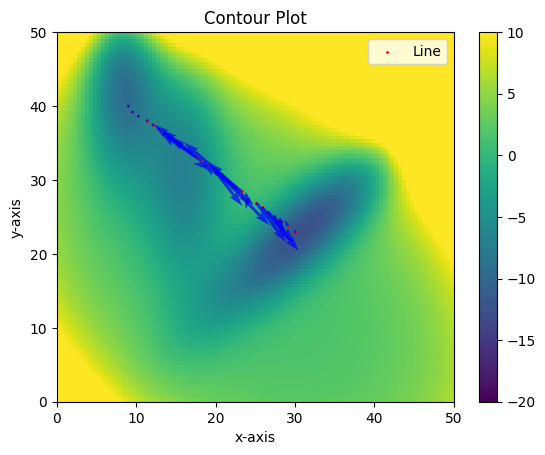

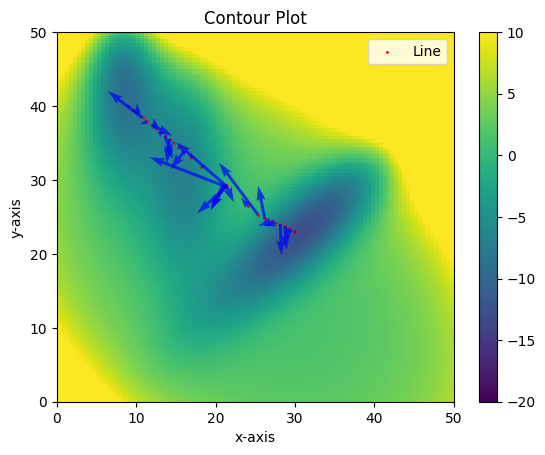

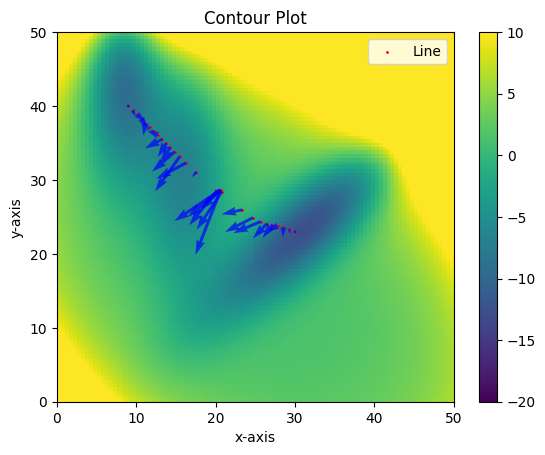

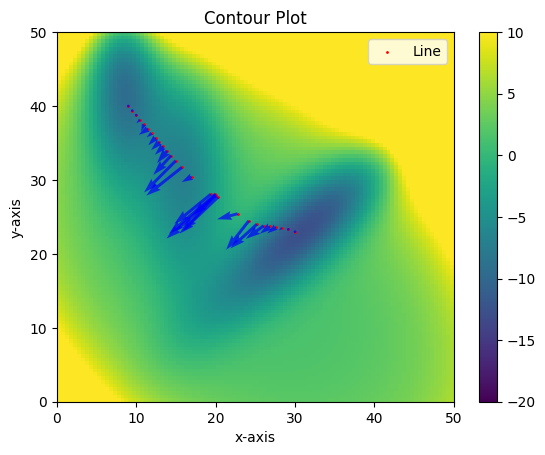

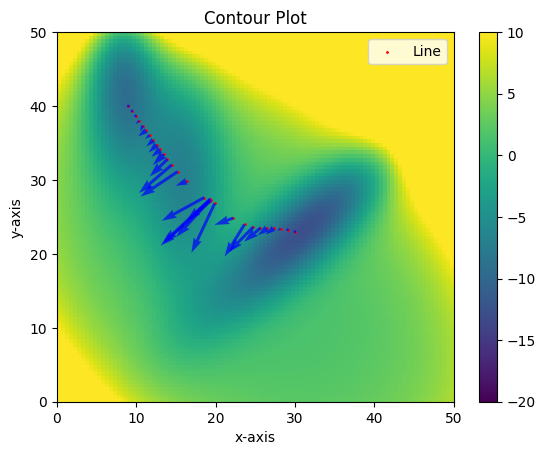

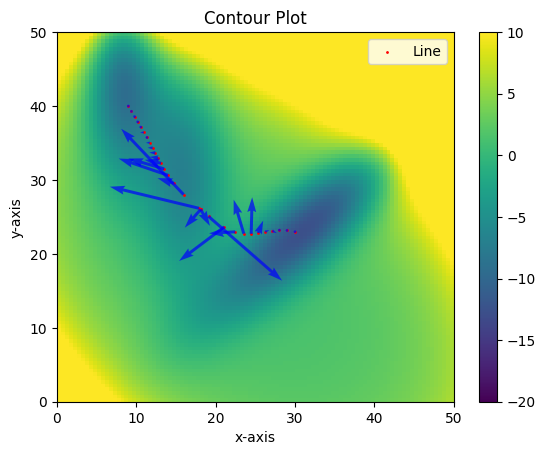

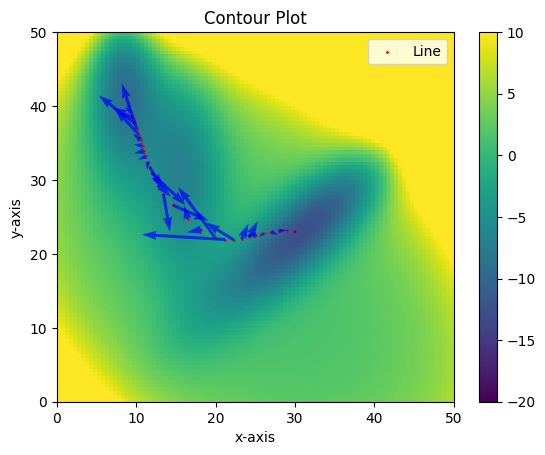

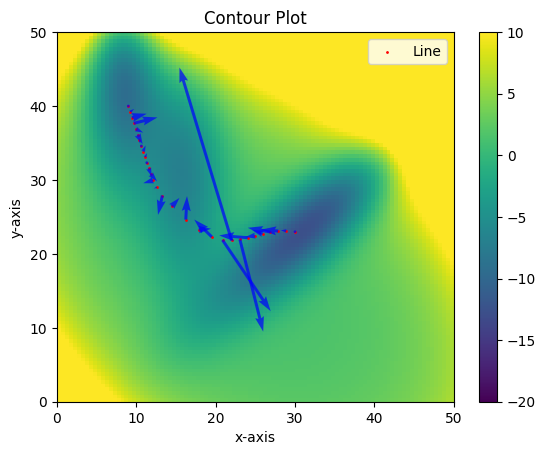

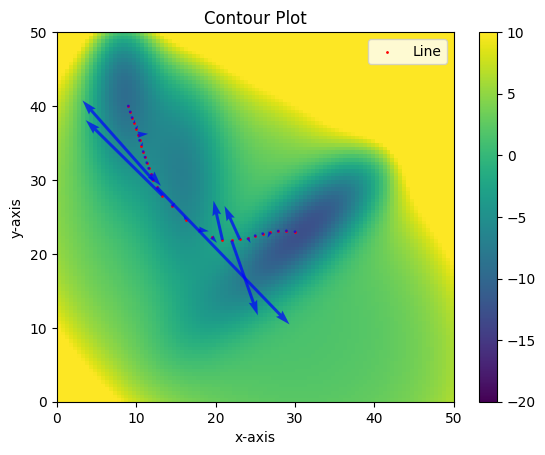

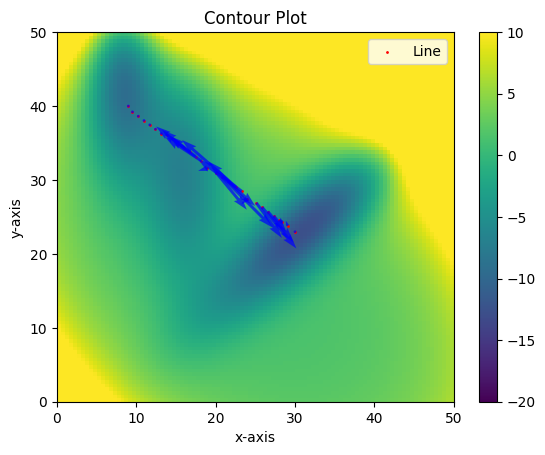

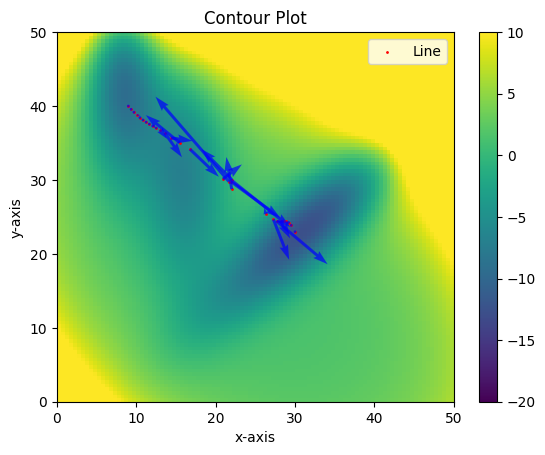

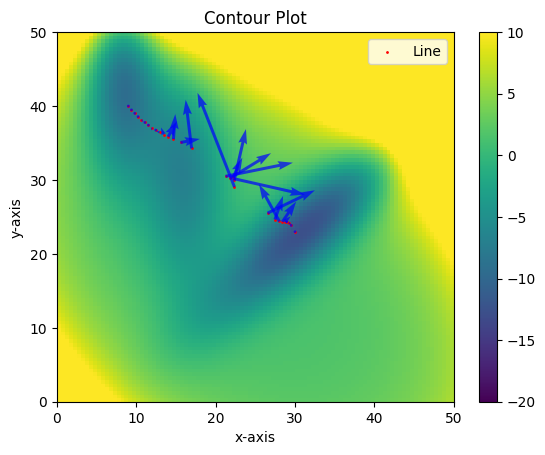

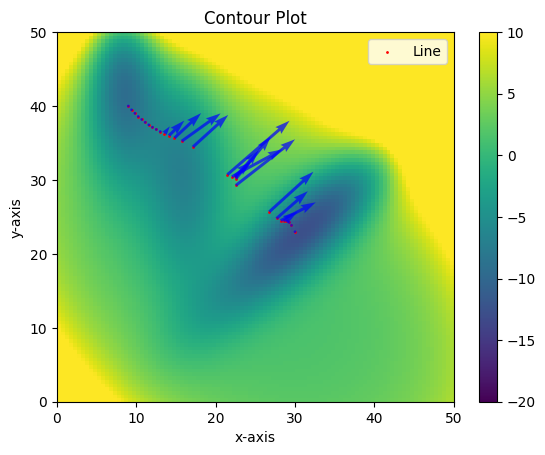

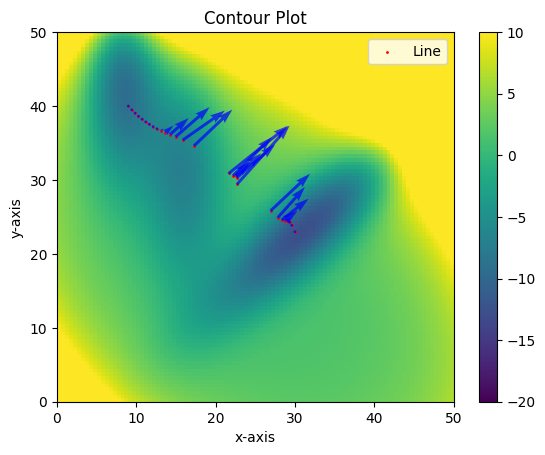

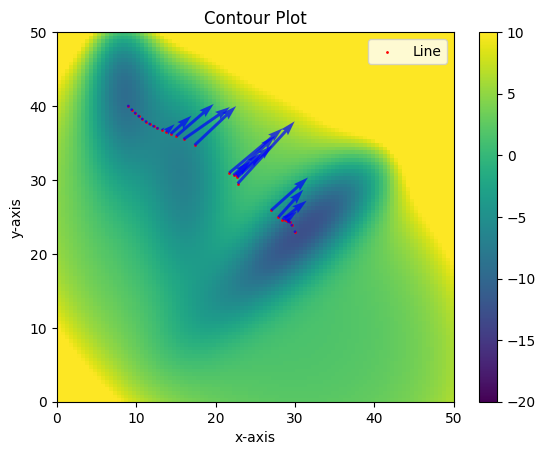

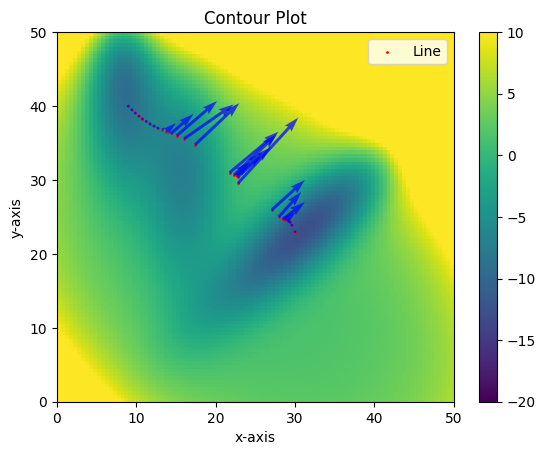

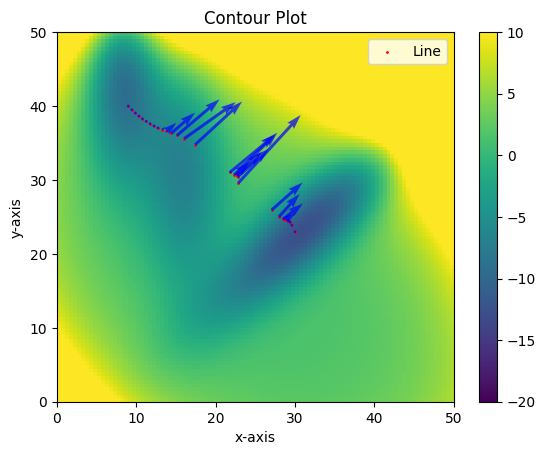

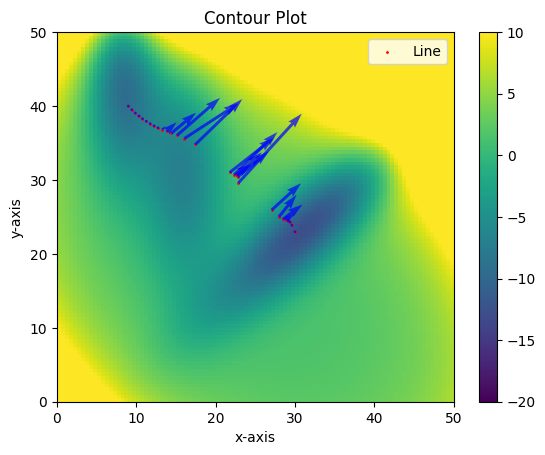

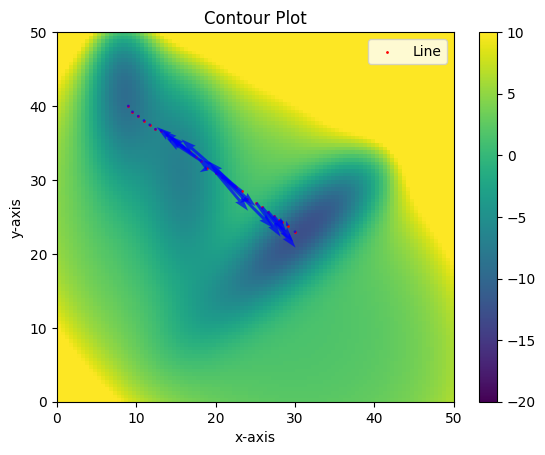

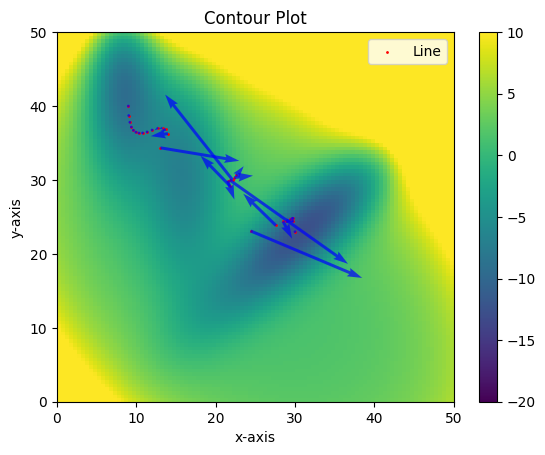

: 

In [8]:
from tqdm import tqdm
import imageio
import wandb
wandb.login()

# Action parameters

line_density = 30 # number of points on the line

# Loop over a bunch of different action parameters
for action_f in [simple_action, S2_action]:
    for xi in torch.logspace(-2, 1, 5).to(args.device):
        for dt in torch.logspace(-2, 0, 5):

            if action_f == simple_action:
                D_loop = [torch.tensor(0.0).to(args.device)]
            else: 
                D_loop = torch.logspace(-1, 2, 5).to(args.device)

            
            for D in D_loop:
                config = {
                    "xi": xi.item(),
                    "dt": dt.item(),
                    "D": D.item(),
                    "action": action_f.__name__,
                }
                wandb.init(project="mb-tests", config=config, name="MB_test")

                action_str = "simple" if action_f == simple_action else "S2"
                print(f'MB_{action_str}_xi={round(xi.item(), 1)}_dt={dt}_D={D.item()}')
                action_func = lambda path: action_f(path, xi, dt, D)
                evaluation_action = lambda path: action_f(path, xi = torch.tensor(0.1).to(args.device), dt = 0.1, D = torch.tensor(10).to(args.device))
                line_x = torch.linspace(x0[1], xf[1],line_density)
                line_y = torch.linspace(x0[0], xf[0], line_density)
                line_points = torch.stack((line_x, line_y), axis=-1).to(args.device)

                iterations = 500
                alpha = 2e-1
                write_every = 50

                optimizer = torch.optim.Adam([line_points], lr = alpha)

                gif_data = []

                #Choose action
                

                # plot the potential
                num_points = 100
                x_values = torch.linspace(potential.Lx, potential.Hx , num_points)
                y_values = torch.linspace(potential.Ly, potential.Hy, num_points)

                x, y = torch.meshgrid(x_values, y_values)
                z = potential.U_split(x.to(args.device), y.to(args.device)).cpu()
                actions = []
                for i in tqdm(range(iterations)):
                    line_points.requires_grad = True
                    action = action_func(line_points)
                    reverse_action = action_func(torch.flip(line_points, dims = (0,)))

                    # It seems likely that they are the same. It probably can be proven
                    total_action = action + reverse_action

                    optimizer.zero_grad()

                    grads, = torch.autograd.grad(total_action, line_points)
                    
                    
                    with torch.no_grad():
                        grads[0,:], grads[-1,:] = torch.zeros(2), torch.zeros(2)
                        line_points.grad = grads
                        optimizer.step()
                        grads = grads.cpu()
                        draw_points = line_points.detach().cpu()
                        

                    if i % write_every == 0:
                        # print(f"Total action for the step {i} is {(action+reverse_action).detach().numpy()}")
                        fig, ax = plt.subplots()
                        colorbar = ax.imshow(z, extent=(x_values.min(), x_values.max(), y_values.min(), y_values.max()), vmin=potential.U_min, vmax=potential.U_max, origin='lower', cmap='viridis', aspect='auto')
                        ax.set(xlabel="x-axis", ylabel="y-axis", title="Contour Plot")
                        plt.colorbar(colorbar)
                        
                        scatter_plot = ax.scatter(draw_points[:,0], draw_points[:,1], s=1, c='red', label='Line')
                        quiver_plot = ax.quiver(draw_points[:,0], draw_points[:,1], -grads[:,0], -grads[:,1], scale_units='xy', angles='xy', color='blue', alpha=0.7)
                        ax.legend()

                        # plt.show()

                        # Save the frame to gif_data

                        fig.canvas.draw()
                        image = np.frombuffer(fig.canvas.tostring_rgb(), dtype='uint8')
                        image = image.reshape(fig.canvas.get_width_height()[::-1] + (3,))
                        gif_data.append(image)
                        eval_action = evaluation_action(line_points) + evaluation_action(torch.flip(line_points, dims = (0,)))
                        actions.append(eval_action.item())

                
    
                action_str = "simple" if action_f == simple_action else "S2"
                imageio.mimsave(f'MB_tests/MB_{action_str}_xi={round(xi.item(), 3)}_dt={round(dt.item(), 3)}_D={round(D.item(), 3)}.gif', gif_data, fps=3)
                log_dict = {"gif": wandb.Video(f'MB_tests/MB_{action_str}_xi={round(xi.item(), 3)}_dt={round(dt.item(), 3)}_D={round(D.item(), 3)}.gif')}
                plt.close(fig)

                # Plot gif of OM actions
                plt.figure()
                plt.plot(np.arange(len(actions)), actions)
                plt.xlabel("Optimization Steps")
                plt.ylabel("OM Action")
                plt.title("OM Action vs Optimization Steps")
                log_dict.update({"OM Action": wandb.Image(plt)})
                plt.close()

                log_dict.update({"final_action": actions[-1]})
                wandb.log(log_dict, step=0)
                wandb.run.summary.update(log_dict)
                wandb.finish()


In [11]:
imageio.mimsave(f'MB_{action_str}_xi={round(xi.item(), 1)}_dt={dt}_D={D.item()}.gif', gif_data, fps=3)